# PyCaret을 이용한 자전거 대여 수요 예측

이 노트북에서는 PyCaret을 사용하여 서울의 자전거 대여 수요 데이터를 분석하고 예측 모델을 구축하는 과정을 학습합니다. 데이터 업로드부터 시각화, 모델링, 예측까지 단계별로 따라가 보세요.

---

## 1. PyCaret 패키지 설치하기

PyCaret은 파이썬 기반의 머신러닝 라이브러리로, 간편하게 다양한 머신러닝 모델을 비교하고 최적의 모델을 찾을 수 있게 도와줍니다. 먼저 PyCaret을 설치해봅시다.

In [ ]:
# PyCaret 패키지 설치
!pip install pycaret

---

## 2. 필요한 라이브러리 불러오기

데이터 처리와 시각화를 위해 필요한 라이브러리들을 불러옵니다.

In [2]:
import pandas as pd
from pycaret.regression import *
from sklearn.model_selection import train_test_split

---

## 3. 파일 불러오기

파일의 이름을 통해 데이터를 불러옵니다. 한국어 인코딩인 'CP949'를 사용하여 파일을 읽어옵니다.

In [3]:
# CSV 파일 업로드
dataset = pd.read_csv('Bike_prepro.csv', encoding='CP949')

# 데이터셋 확인 (상위 6개 행)
print(dataset.head())

         Date  Rented.Bike.Count  Hour  Temperature  Humidity  Wind.speed  \
0  01/12/2017                254     0         -5.2        37         2.2   
1  01/12/2017                204     1         -5.5        38         0.8   
2  01/12/2017                173     2         -6.0        39         1.0   
3  01/12/2017                107     3         -6.2        40         0.9   
4  01/12/2017                 78     4         -6.0        36         2.3   

   Visibility  Dew.point.temperature  Solar.Radiation  Rainfall  Snowfall  \
0        2000                  -17.6              0.0       0.0       0.0   
1        2000                  -17.6              0.0       0.0       0.0   
2        2000                  -17.7              0.0       0.0       0.0   
3        2000                  -17.6              0.0       0.0       0.0   
4        2000                  -18.6              0.0       0.0       0.0   

   Seasons  Holiday  Functioning.Day  
0        4        1                

In [4]:
dataset.describe()

,Rented.Bike.Count,Hour,Temperature,Humidity,Wind.speed,Visibility,Dew.point.temperature,Solar.Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning.Day
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068,2.490411,0.950685,0.966324
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746,1.116831,0.216537,0.180404
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000,2.000000,1.000000,1.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000,3.000000,1.000000,1.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000,4.000000,1.000000,1.000000


---

## 4. 데이터 분포 시각화: 히스토그램

`Rented.Bike.Count` 변수의 분포를 히스토그램으로 시각화하여 데이터의 전반적인 분포를 확인합니다.

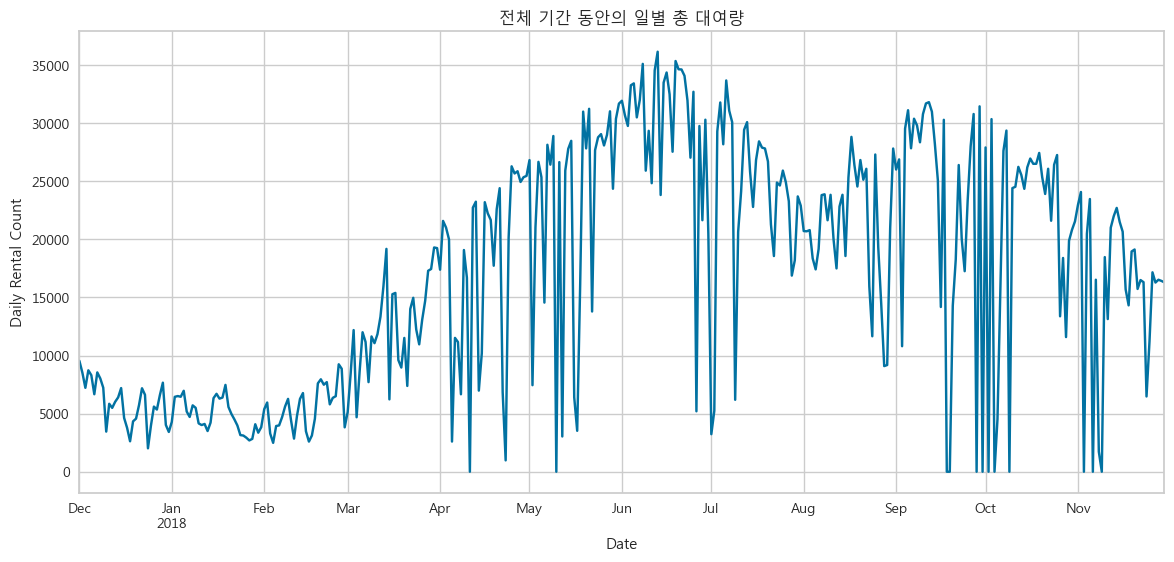

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'Malgun Gothic'   # 윈도우 기본 한글 폰트
dataset['Date'] = pd.to_datetime(dataset['Date'], format="%d/%m/%Y")
daily_sum = dataset.groupby('Date')['Rented.Bike.Count'].sum()

plt.figure(figsize=(14, 6))
daily_sum.plot()
plt.title('전체 기간 동안의 일별 총 대여량')
plt.xlabel('Date')
plt.ylabel('Daily Rental Count')
plt.grid(True)
plt.show()

---

## 5. 데이터 분포 시각화: 시간별 박스플롯

시간(`Hour`)에 따른 자전거 대여 수(`Rented.Bike.Count`)의 분포를 박스플롯으로 나타내어 시간대별 변동을 분석합니다.

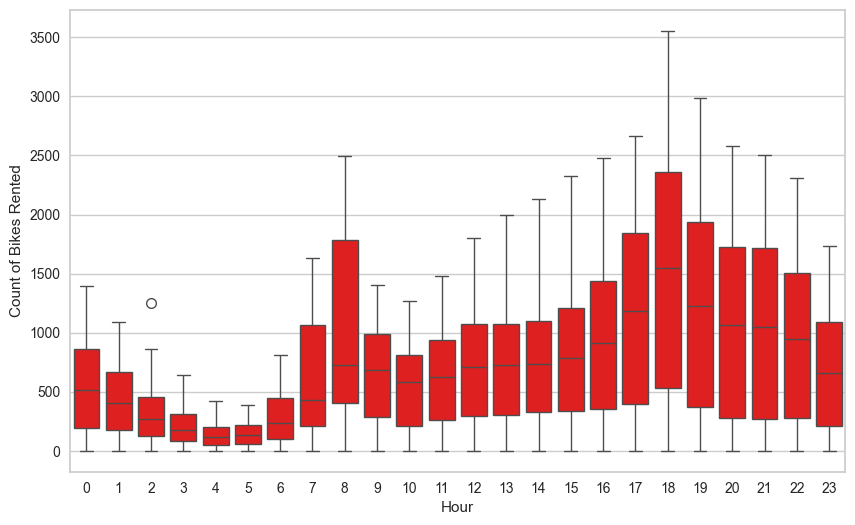

In [8]:
# 박스플롯 생성
plt.figure(figsize=(10, 6))
sns.boxplot(data=dataset, x='Hour', y='Rented.Bike.Count', color='red')

# 라벨 설정
plt.xlabel('Hour')
plt.ylabel('Count of Bikes Rented')

# 그래프 출력
plt.show()

---

## 6. 데이터 분포 시각화: 계절별 박스플롯

계절(`Seasons`)에 따른 자전거 대여 수의 분포를 박스플롯으로 시각화하여 계절별 패턴을 확인합니다.

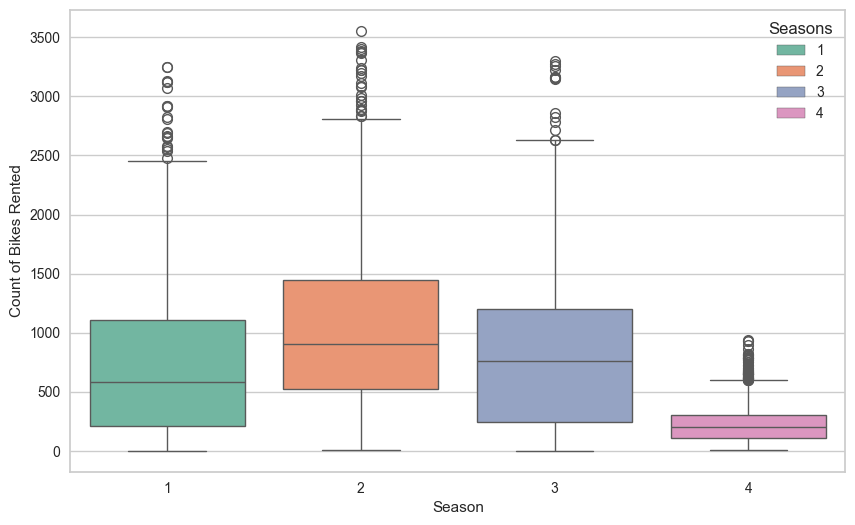

In [9]:
# 박스플롯 생성
plt.figure(figsize=(10, 6))
sns.boxplot(data=dataset, x='Seasons', y='Rented.Bike.Count', hue='Seasons', palette='Set2')

# 라벨 설정
plt.xlabel('Season')
plt.ylabel('Count of Bikes Rented')

# 범례 위치 조정
plt.legend(loc='upper right', title='Seasons')

# 그래프 출력
plt.show()

---

## 7. 데이터 분포 시각화: 휴일 여부별 박스플롯

휴일(`Holiday`) 여부에 따른 자전거 대여 수의 분포를 박스플롯으로 나타냅니다.

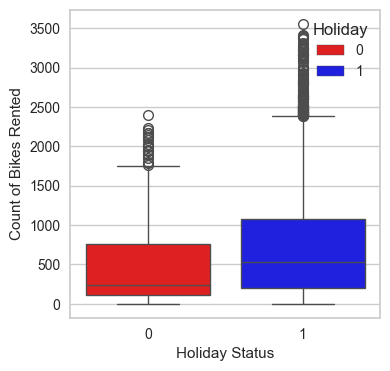

In [10]:
# 박스플롯 생성
plt.figure(figsize=(4, 4))
sns.boxplot(data=dataset, x='Holiday', y='Rented.Bike.Count', hue='Holiday', palette=['red', 'blue'])

# 라벨 설정
plt.xlabel('Holiday Status')
plt.ylabel('Count of Bikes Rented')

# 범례 위치 조정
plt.legend(loc='upper right', title='Holiday')

# 그래프 출력
plt.show()

---

## 8. 데이터 관계 시각화: 온도와 대여 수의 산점도

온도(`Temperature`)와 자전거 대여 수 간의 관계를 산점도로 시각화하고, 회귀선을 추가하여 상관관계를 분석합니다.

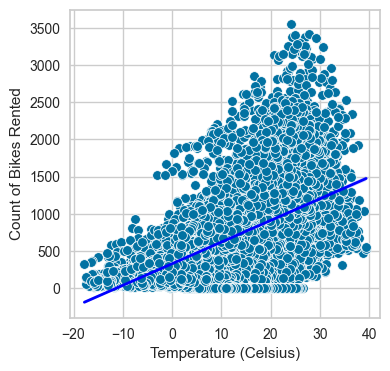

In [11]:
# 산점도 생성
plt.figure(figsize=(4, 4))
sns.scatterplot(data=dataset, x='Temperature', y='Rented.Bike.Count')

# 회귀선 추가
sns.regplot(data=dataset, x='Temperature', y='Rented.Bike.Count', scatter=False, color='blue', line_kws={'lw': 2})

# 그래프 라벨 설정
plt.xlabel('Temperature (Celsius)')
plt.ylabel('Count of Bikes Rented')

# 그래프 출력
plt.show()

---

## 9. 입력 변수와 종속 변수 분리하기

모델링을 위해 입력 변수(`X`)와 종속 변수(`y`)를 분리합니다. 여기서 `Rented.Bike.Count`가 예측하려는 목표 변수입니다.

In [12]:
# 입력 변수와 종속 변수 분리하기
y = dataset['Rented.Bike.Count']
X = dataset.iloc[:, 2:]  # 필요한 열을 선택 (예: 3번째 열부터)

---

## 10. 데이터셋 분리하기: 훈련 세트와 테스트 세트

데이터를 훈련 세트와 테스트 세트로 분리하여 모델의 성능을 평가할 준비를 합니다. 테스트 세트 비율은 30%로 설정하고, 재현성을 위해 랜덤 시드를 고정합니다.

In [13]:
# 데이터셋 분리하기
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 훈련 데이터셋 재구성
train_data = pd.concat([X_train, y_train], axis=1)

---

## 11. PyCaret 환경 설정하기

PyCaret을 사용하여 머신러닝 실험 환경을 설정합니다. `setup` 함수는 데이터 전처리, 특성 공학 등을 자동으로 수행해줍니다.

In [ ]:
# PyCaret 환경 설정
exp = setup(data=train_data, target='Rented.Bike.Count', session_id=123)

,Description,Value
0,Session id,123
1,Target,Rented.Bike.Count
2,Target type,Regression
3,Original data shape,"(6132, 13)"
4,Transformed data shape,"(6132, 13)"
5,Transformed train set shape,"(4292, 13)"
6,Transformed test set shape,"(1840, 13)"
7,Numeric features,12
8,Preprocess,True
9,Imputation type,simple


---

## 12. 모델 비교하기: AutoML 활용

PyCaret의 `compare_models` 함수를 사용하여 다양한 회귀 모델을 자동으로 비교하고 최적의 모델을 선택합니다.

In [15]:
# AutoML을 사용하여 모델 비교하기
best_model = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,144.9286,51530.4073,226.7331,0.8719,0.9615,0.5134,0.0520
et,Extra Trees Regressor,140.4681,52154.6796,227.9965,0.8704,0.6393,0.5451,0.0830
rf,Random Forest Regressor,147.9224,58053.4633,240.6185,0.8557,0.7094,0.5528,0.1350
gbr,Gradient Boosting Regressor,172.0014,65564.0119,255.4033,0.8379,1.0320,0.7560,0.0480
dt,Decision Tree Regressor,197.7009,112825.9752,335.4049,0.7198,0.7241,0.5803,0.0070
ada,AdaBoost Regressor,369.6506,187721.8057,432.9279,0.5341,1.5676,2.3928,0.0280
lar,Least Angle Regression,328.5580,192154.7508,437.7087,0.5257,1.3712,1.5190,0.0040
br,Bayesian Ridge,328.5135,192168.7906,437.7177,0.5257,1.3724,1.5173,0.0050
ridge,Ridge Regression,328.5426,192153.4859,437.7053,0.5257,1.3714,1.5186,0.0030
lr,Linear Regression,328.5580,192154.7508,437.7087,0.5257,1.3712,1.5190,1.8300


---

## 13. 모델 학습 시각화: 특성 중요도와 잔차

선택된 최적의 모델에 대해 특성 중요도와 잔차를 시각화하여 모델의 성능과 예측 오류를 분석합니다.

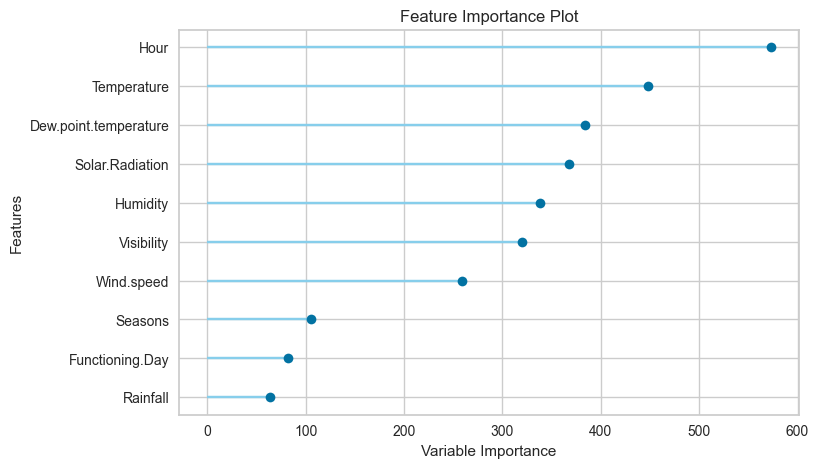

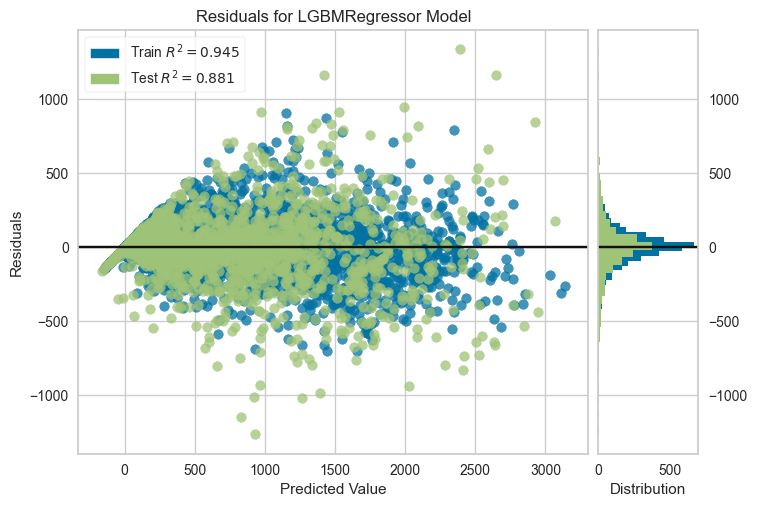

In [16]:
# 모델의 특성 중요도 시각화
plot_model(best_model, plot='feature')  # Feature Importance Plot

# 모델의 잔차 시각화
plot_model(best_model, plot='residuals')  # Residuals Plot

---

## 14. 테스트 데이터에 대한 예측 수행하기

훈련된 모델을 사용하여 테스트 데이터에 대한 예측을 수행하고, 예측 결과를 확인합니다.

In [17]:
# 테스트 데이터셋 준비
y_test = pd.DataFrame(y_test, columns=['Rented.Bike.Count']).reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
test_data = pd.concat([X_test, y_test], axis=1)

# 예측 수행
predictions = predict_model(best_model, data=test_data)

# 예측 결과 출력
print(predictions)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,145.6766,54842.5742,234.1849,0.8662,0.9125,0.4638


      Hour  Temperature  Humidity  Wind.speed  Visibility  \
0        8    27.200001        69         1.8        1999   
1       12    32.599998        51         2.1         800   
2       14    34.000000        50         1.2        1744   
3       18    16.900000        47         1.4        1637   
4        7     6.400000        51         1.0        1398   
...    ...          ...       ...         ...         ...   
2623    20    19.100000        18         1.2        2000   
2624    16     5.100000        16         1.8        1998   
2625    20    12.600000        47         3.2        1935   
2626    23    -1.000000        55         1.9        2000   
2627    21     4.100000        55         1.2        1448   

      Dew.point.temperature  Solar.Radiation  Rainfall  Snowfall  Seasons  \
0                 21.000000             0.70       0.0       0.0        2   
1                 21.100000             3.21       0.0       0.0        2   
2                 22.100000         

---

## 15. 모델 성능 평가하기

예측된 값과 실제 값을 비교하여 모델의 성능을 평가합니다. PyCaret은 다양한 성능 지표를 제공하므로 이를 활용할 수 있습니다.

In [18]:
# 모델 성능 평가
evaluate_model(best_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

---

## 16. 최적 모델 저장하기

훈련된 최적의 모델을 저장하여 나중에 다시 사용할 수 있도록 합니다.

In [19]:
# 모델 저장
save_model(best_model, 'Best_Bike_Rental_Model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['Hour', 'Temperature', 'Humidity',
                                              'Wind.speed', 'Visibility',
                                              'Dew.point.temperature',
                                              'Solar.Radiation', 'Rainfall',
                                              'Snowfall', 'Seasons', 'Holiday',
                                              'Functioning.Day'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=[],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('clean_column_names',
                  TransformerWrapper(transformer=CleanColumnNames())),
                 ('trained_model', LGBMRegressor(n_jobs=-1, random_state=123))]),
 'Best_Bike_Rental_Model.pkl'

---

## 17. 저장된 모델 불러오기

저장된 모델을 불러와서 새로운 데이터에 대해 예측을 수행할 수 있습니다.

In [20]:
# 모델 불러오기
loaded_model = load_model('Best_Bike_Rental_Model')

# 새로운 데이터에 대한 예측 수행 (예시)
# new_predictions = predict_model(loaded_model, data=new_data)

Transformation Pipeline and Model Successfully Loaded


---

## 18. 결론

이번 노트북에서는 PyCaret을 활용하여 서울의 자전거 대여 수요 데이터를 분석하고 예측 모델을 구축하는 과정을 학습했습니다. 데이터 시각화를 통해 데이터의 특성을 이해하고, PyCaret의 AutoML 기능을 통해 최적의 모델을 손쉽게 찾을 수 있었습니다. 이를 바탕으로 실제 비즈니스 문제에 적용하여 효율적인 의사결정을 내릴 수 있을 것입니다.

---